## Activity: Build a K-means model

In this activity, you are a consultant for a scientific organization that works to support and sustain penguin colonies. You are tasked with helping other staff members learn more about penguins in order to achieve this mission.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [4]:
# Import the data
raw_penguins = pd.read_csv('./raw_data/penguins.csv')
raw_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [5]:
raw_penguins['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [6]:
raw_penguins['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [7]:
raw_penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [12]:
penguins_data = raw_penguins.dropna(axis=0).reset_index(drop=True)

In [9]:
penguins_data['sex'].unique()

array(['male', 'female'], dtype=object)

In [13]:
# Encode data / Feature-Data Transformation

penguins_data = pd.get_dummies(penguins_data,drop_first=True,columns=['sex'],dtype=int)
penguins_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_male
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,1


In [14]:
penguins_data = penguins_data.drop(['island'],axis=1)

In [22]:
x = penguins_data.drop(['species'],axis=1)
y = penguins_data.loc[:,['species']]

x.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_male
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,0.504505
std,5.468668,1.969235,14.015765,805.215802,0.500732
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.500000,15.600000,190.000000,3550.000000,0.000000
50%,44.500000,17.300000,197.000000,4050.000000,1.000000
75%,48.600000,18.700000,213.000000,4775.000000,1.000000
max,59.600000,21.500000,231.000000,6300.000000,1.000000


In [26]:
x_normalized = MinMaxScaler().fit_transform(x)
x_norm_df = pd.DataFrame(x_normalized)
x_norm_df.describe()

,0,1,2,3,4
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,0.432465,0.483912,0.490966,0.418627,0.504505
std,0.198861,0.234433,0.237555,0.223671,0.500732
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.269091,0.297619,0.305085,0.236111,0.000000
50%,0.450909,0.500000,0.423729,0.375000,1.000000
75%,0.600000,0.666667,0.694915,0.576389,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='cluster', ylabel='inertia'>

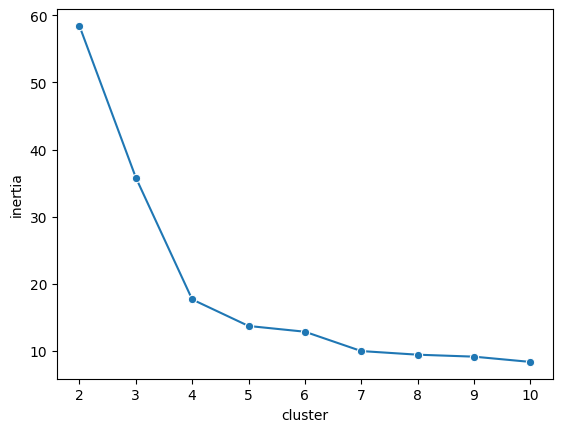

In [28]:
# Used the elbow method to get the right number of clusters
# In reality I know that the optimal should be 3 clusters or 6 3 species * 2 sex classes

n_clusters = []
inertia_score = []

for i in range(2,11):
    kmean_n = KMeans(n_clusters=i,random_state=42).fit(x_normalized)
    inertia_score.append(kmean_n.inertia_)
    n_clusters.append(i)

model_cluster_df = pd.DataFrame({
    'cluster': n_clusters,
    'inertia':inertia_score
})

sns.lineplot(
    data= model_cluster_df,
    x = 'cluster',
    y = 'inertia',
    marker= 'o'
)



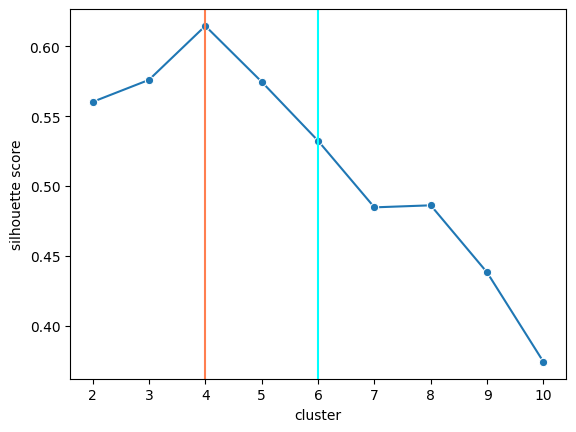

In [45]:
# Evaluate the models by the silhouette score

n_cls = []
sil_score = []

for i in range(2,11):
    kmean_n = KMeans(n_clusters=i,random_state=42).fit(x_normalized)
    sil_scr = silhouette_score(x_normalized,kmean_n.labels_)
    n_cls.append(i)
    sil_score.append(sil_scr)

sil_df = pd.DataFrame({
    'cluster':n_cls,
    'silhouette score': sil_score
})

sns.lineplot(
    data=sil_df,
    x='cluster',
    y ='silhouette score',
    marker= 'o'
)

plt.axvline(4,color='coral')
plt.axvline(6,color='cyan')

In [50]:
# Build a k-means model with 6 clusters
# each specie-sex conbination will be a cluster

kmean_6c = KMeans(n_clusters=6,random_state=42).fit(x_normalized)
print(f'For a 6 clusters model the metrics are:\n  Inertia: {kmean_6c.inertia_:.6f}\n  Silhouette Score: {silhouette_score(x_normalized,kmean_6c.labels_):.6f}')

For a 6 clusters model the metrics are:
  Inertia: 12.885268
  Silhouette Score: 0.532378


In [ ]:
model_predictions = pd.DataFrame({
    'speciesPredicted': kmean_6c.predict(x_normalized)
})

results_df = y.join(model_predictions)
penguin = x.join(results_df)

penguin

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_male,species,speciesPredicted
0,39.1,18.7,181.0,3750.0,1,Adelie,2
1,39.5,17.4,186.0,3800.0,0,Adelie,0
2,40.3,18.0,195.0,3250.0,0,Adelie,0
3,36.7,19.3,193.0,3450.0,0,Adelie,0
4,39.3,20.6,190.0,3650.0,1,Adelie,2
...,...,...,...,...,...,...,...
328,47.2,13.7,214.0,4925.0,0,Gentoo,3
329,46.8,14.3,215.0,4850.0,0,Gentoo,3
330,50.4,15.7,222.0,5750.0,1,Gentoo,1
331,45.2,14.8,212.0,5200.0,0,Gentoo,3


In [89]:
penguin.groupby(by=['species','sex_male'])['sex_male'].value_counts()

species    sex_male
Adelie     0           73
           1           73
Chinstrap  0           34
           1           34
Gentoo     0           58
           1           61
Name: count, dtype: int64

In [87]:
for cls in np.unique(kmean_6c.labels_):
    print(f'Cluster: {cls}')
    specie_info = penguin[penguin['speciesPredicted']==cls]
    print('=='*15)
    print(f'Cluster predictions: {specie_info.shape[0]}')
    print(specie_info.groupby(['species','sex_male'])['speciesPredicted'].value_counts())
    print('=='*15)

Cluster: 0
Cluster predictions: 107
species    sex_male  speciesPredicted
Adelie     0         0                   73
Chinstrap  0         0                   34
Name: count, dtype: int64
Cluster: 1
Cluster predictions: 61
species  sex_male  speciesPredicted
Gentoo   1         1                   61
Name: count, dtype: int64
Cluster: 2
Cluster predictions: 36
species  sex_male  speciesPredicted
Adelie   1         2                   36
Name: count, dtype: int64
Cluster: 3
Cluster predictions: 58
species  sex_male  speciesPredicted
Gentoo   0         3                   58
Name: count, dtype: int64
Cluster: 4
Cluster predictions: 34
species    sex_male  speciesPredicted
Chinstrap  1         4                   34
Name: count, dtype: int64
Cluster: 5
Cluster predictions: 37
species  sex_male  speciesPredicted
Adelie   1         5                   37
Name: count, dtype: int64
